# E2b — E2a 후속: 표면 정보 vs 내부 지식 분리

**목표:** hidden의 K± 신호가 질문 표면(단어·속성·엔티티 인지도)으로 설명되지 않는 내부 지식인지, 어느 층에서 형성되는지 확인한다.

| 실험 | 질문 | 판단 기준 |
|---|---|---|
| 0 재현 | 데이터 정렬이 E2a와 같은가 | E2a 4개 값과 ±0.005 이내 (GroupKFold 동일 조건) |
| A Leave-one-prop-out | 처음 보는 속성에서도 K를 읽는가 | LOPO AUROC > 0.5, 순열 p < 0.05 |
| B 층별 증분 | 표면 대비 hidden 증분이 어느 층에서 생기는가 | ΔAUROC 95% CI > 0 |
| C 표면 제거 후 재probe | 표면 성분을 지운 표현에도 K가 남는가 | 잔차·INLP 후 AUROC > 0.5 |
| D Control task | probe가 속성 기저율을 암기하는가 | selectivity = 실제 − 셔플 AUROC |
| E 엔티티 인지도 | 인지도 통제 후에도 증분이 남는가 | 인지도 포함 ΔAUROC CI > 0 |

**입력:** E2a와 같은 `new_data/` (`p8s_v2_h_out.npy`, `p8s_behavior_v2.csv`). 이전 노트북 실행은 필요 없다.

**실행 순서:** 1 → 2(경로 확인) → 3 → 4 → 5-1(E2a 정확 재현, 통과 필수) → 5-2 → 6~10 → 11.
GPU는 쓰지 않는다. A100 런타임은 CPU 코어·RAM 확보용이다.

In [1]:
# ===== 1. 환경 =====
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ===== 2. CONFIG — E2a(다영, 0-based) 산출물 기준 =====
ND = '/content/drive/MyDrive/new_data/'        # E2a와 같은 new_data 폴더 (바로가기 위치에 맞게 수정)
HIDDEN_PATH = ND + 'hidden/p8s_v2_h_out.npy'  # (1224, 32, 4096) fp16, index i == model.model.layers[i]
META_PATH   = ND + 'hidden/p8s_v2_meta.json'
LABELS_PATH = ND + 'labels/p8s_behavior_v2.csv'
OUT_DIR     = '/content/drive/MyDrive/p8s/E2b_surface_vs_knowledge'
HIDDEN_ZIP = LABELS_ZIP = None; WORK_DIR = '/content/e2b_tmp'
HIDDEN_ROWID_PATH = None; HIDDEN_GLOB = '*'; HIDDEN_KEY = 'h_out'; DROP_FIRST_LAYER = False

# 라벨 컬럼 (E2a와 동일). None이면 후보 목록에서 자동 탐색
ID_COL    = 'rid'          # 없으면 행 번호로 생성
GROUP_COL = 'question'     # E2a와 동일하게 질문 텍스트로 그룹
Q_COL     = 'question'
K_COL     = 'kside_corr'
K_COL_ALT = 'kside_new'
C_COL     = 'ctx_label'
PROP_COL  = None           # 후보: prop, property, relation
SUBJ_COL  = None           # 후보: s_wiki_title, subj, subject
POP_COL   = None           # 후보: s_pop (PopQA 계열이면 위키 월 조회수가 이미 있음 → API 생략)

# fold: 'stratified_group' = 팀 합의(K 균등 + 질문 그룹) / 'group' = E2a 원본(GroupKFold)
FOLD_MODE = 'stratified_group'

SEED, N_FOLDS = 0, 5
PROBE_C, SURF_C = 0.1, 1.0
PCA_DIM, N_BOOT, N_PERM, N_CTRL, INLP_ITERS, MIN_PROP_ROWS = 256, 1000, 1000, 5, 10, 20
LAYERS_C = [0, 2, 4, 7, 9, 11, 13, 15, 19, 23, 27, 31]
# E2a 원본 결과 (GroupKFold, fold별 AUROC 평균) — 5번 셀에서 같은 방식으로 정확 재현 확인
EXPECT = {'kside_new': (9, 0.7880), 'kside_k': (9, 0.8064), 'kside_corr': (9, 0.8187), 'C': (15, 0.9354)}
WIKI_UA = 'EwhaGradProject-E2b/1.0 (contact: YOUR_EMAIL)'

In [3]:
# ===== 3. 로드 =====
import os, glob, re, warnings, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy import sparse
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score
warnings.filterwarnings('ignore')
N_JOBS = os.cpu_count()
os.makedirs(OUT_DIR, exist_ok=True); os.makedirs(WORK_DIR, exist_ok=True)
print('CPU cores:', N_JOBS)

for z, d in [(HIDDEN_ZIP, f'{WORK_DIR}/hidden'), (LABELS_ZIP, f'{WORK_DIR}/labels')]:
    if z and os.path.exists(z) and not os.path.exists(d):
        os.system(f'unzip -q -o "{z}" -d "{d}"')
os.system(f'find "{WORK_DIR}" -maxdepth 3 | head -40')

def _natkey(s): return [int(t) if t.isdigit() else t for t in re.split(r'(\d+)', s)]

def _load_one(f):
    if f.endswith('.npy'):
        a = np.load(f)
    elif f.endswith('.npz'):
        z = np.load(f); a = z[HIDDEN_KEY] if HIDDEN_KEY in z.files else z[z.files[0]]
    elif f.endswith(('.pt', '.pth', '.safetensors')):
        import torch
        if f.endswith('.safetensors'):
            from safetensors.torch import load_file; a = load_file(f)
        else:
            a = torch.load(f, map_location='cpu')
        if isinstance(a, dict): a = a[HIDDEN_KEY] if HIDDEN_KEY in a else next(iter(a.values()))
        a = a.float().numpy()
    else:
        raise ValueError(f)
    return np.asarray(a, dtype=np.float32)

def load_hidden(path):
    if os.path.isfile(path):
        return _load_one(path)
    exts = ('.npy', '.npz', '.pt', '.pth', '.safetensors')
    files = sorted([f for f in glob.glob(os.path.join(path, '**', HIDDEN_GLOB), recursive=True)
                    if f.endswith(exts)], key=_natkey)
    print(f'hidden files: {len(files)}', files[:3])
    if len(files) == 1: return _load_one(files[0])
    return np.stack([_load_one(f) for f in files], 1)   # 층별 파일 (N, D) → (N, L, D)

def read_table(p):
    if p.endswith('.csv'): return pd.read_csv(p)
    if p.endswith('.jsonl'): return pd.read_json(p, lines=True)
    if p.endswith('.json'): return pd.read_json(p)
    if p.endswith('.parquet'): return pd.read_parquet(p)
    raise ValueError(p)

def to_bin(s):
    # E2a 규약: 'K+…'/'C+…'로 시작하면 1. 숫자·불리언도 허용
    def f(v):
        if isinstance(v, (bool, np.bool_)): return int(v)
        if isinstance(v, (int, float, np.integer, np.floating)): return int(v > 0)
        v = str(v).strip().replace('−', '-')
        if len(v) >= 2 and v[1] in '+-': return int(v[1] == '+')
        if v[:1] in '+-': return int(v[0] == '+')
        if v.lower() in ('1', 'true', 'pos'): return 1
        if v.lower() in ('0', 'false', 'neg'): return 0
        raise ValueError(f'라벨 해석 불가: {v}')
    return s.map(f).astype(int).values

df = read_table(LABELS_PATH)
if ID_COL not in df.columns: df[ID_COL] = np.arange(len(df))
if HIDDEN_ROWID_PATH:
    rid = np.load(HIDDEN_ROWID_PATH, allow_pickle=True) if HIDDEN_ROWID_PATH.endswith('.npy') \
          else read_table(HIDDEN_ROWID_PATH).iloc[:, 0].values
    df = df.set_index(ID_COL).loc[rid].reset_index()

H = load_hidden(HIDDEN_PATH)
N = len(df)
if H.shape[0] != N and H.shape[1] == N: H = H.transpose(1, 0, 2)
if DROP_FIRST_LAYER: H = H[:, 1:]
assert H.ndim == 3 and H.shape[0] == N, f'hidden {H.shape} vs labels {N}'
NL = H.shape[1]
print('H:', H.shape, '| labels:', df.shape)

print('labels 컬럼:', list(df.columns))
def pick(cur, cands):
    if cur and cur in df.columns: return cur
    for c in cands:
        if c in df.columns: return c
    return None
PROP_COL = pick(PROP_COL, ['prop', 'property', 'relation'])
SUBJ_COL = pick(SUBJ_COL, ['s_wiki_title', 'subj', 'subject'])
POP_COL  = pick(POP_COL,  ['s_pop'])
print(f'PROP_COL={PROP_COL} | SUBJ_COL={SUBJ_COL} | POP_COL={POP_COL}')
assert PROP_COL, 'prop 컬럼 없음 → p8s 원본 csv에서 question 키로 merge 필요'
if os.path.exists(META_PATH):
    import json; meta = json.load(open(META_PATH))
    print('meta:', {k: meta.get(k) for k in ('row_order', 'layer_index', 'position')})
if N == 1224:
    print('앞 612행 = 뒤 612행 질문 순서:', bool((df[Q_COL].values[:612] == df[Q_COL].values[612:]).all()))

yK = to_bin(df[K_COL]); yC = to_bin(df[C_COL])
yK_alt = to_bin(df[K_COL_ALT]) if K_COL_ALT and K_COL_ALT in df.columns else None
groups = df[GROUP_COL].astype(str).values
props  = df[PROP_COL].astype(str).values
qtext  = df[Q_COL].astype(str).values
assert (df.groupby(GROUP_COL)[K_COL].nunique() == 1).all(), '같은 질문 안에서 K가 달라짐 — GROUP_COL 확인'
print(f'K+ {yK.mean():.3f} | C+ {yC.mean():.3f} | 질문 {len(np.unique(groups))} | prop {len(np.unique(props))}')

CPU cores: 12
H: (1224, 32, 4096) | labels: (1224, 26)
labels 컬럼: ['question', 'gold', 'prop', 'kside', 'knows', 'A_cb', 'ctx_id', 'ctx_title', 's_wiki_title', 'orig_gold', 'ctx_label', 'ctx_text', 'answer_surface', 'ans_start', 'ans_end', 'wrong_answer', 'answer', 'behavior', 'final_correct', 'gold_list', 'kside_k', 'kside_new', 'kside_corr', 'k_agree', 'cell_k', 'rid']
PROP_COL=prop | SUBJ_COL=s_wiki_title | POP_COL=None
meta: {'row_order': 'p8s_behavior.csv의 행 순서 그대로 (0..1223)', 'layer_index': '0-based; index i == model.model.layers[i]', 'position': 'last prefill token (left padding, [:, -1, :])'}
앞 612행 = 뒤 612행 질문 순서: True
K+ 0.592 | C+ 0.500 | 질문 612 | prop 16


In [4]:
# ===== 4. fold · 공통 함수 =====
from sklearn.model_selection import GroupKFold
def make_folds(y, g, seed=SEED, mode=None):
    mode = mode or FOLD_MODE
    fold = np.full(len(y), -1)
    sp = GroupKFold(n_splits=N_FOLDS) if mode == 'group' else \
         StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)
    for i, (_, te) in enumerate(sp.split(np.zeros(len(y)), y, g)): fold[te] = i
    return fold

FOLD = make_folds(yK, groups)
pd.DataFrame({ID_COL: df[ID_COL], GROUP_COL: groups, 'fold': FOLD}).to_csv(f'{OUT_DIR}/fold_assignment.csv', index=False)
print('fold별 행수 / K+ 비율:', [(int((FOLD == k).sum()), round(yK[FOLD == k].mean(), 3)) for k in range(N_FOLDS)])

def auc(y, s): return roc_auc_score(y, s) if len(np.unique(y)) == 2 else np.nan
def lr(C): return LogisticRegression(C=C, max_iter=3000)
def probe(C=PROBE_C): return make_pipeline(StandardScaler(), lr(C))

def oof(X, y, fold, C=PROBE_C):
    s = np.zeros(len(y))
    for k in range(N_FOLDS):
        tr, te = fold != k, fold == k
        s[te] = probe(C).fit(X[tr], y[tr]).decision_function(X[te])
    return s

def pca_block(Xtr, Xte, dim=PCA_DIM):
    sc = StandardScaler().fit(Xtr)
    p = PCA(min(dim, Xtr.shape[0] - 1, Xtr.shape[1]), random_state=SEED).fit(sc.transform(Xtr))
    Ztr, Zte = p.transform(sc.transform(Xtr)), p.transform(sc.transform(Xte))
    zs = StandardScaler().fit(Ztr)
    return zs.transform(Ztr), zs.transform(Zte)

_rng = np.random.default_rng(SEED)
_ug = np.unique(groups); _pos = {g: np.where(groups == g)[0] for g in _ug}
BOOT = [np.concatenate([_pos[g] for g in _rng.choice(_ug, len(_ug))]) for _ in range(N_BOOT)]

def boot_delta(y, s_a, s_b):
    # 질문 단위 paired bootstrap: AUROC(b) − AUROC(a)
    d = np.array([auc(y[i], s_b[i]) - auc(y[i], s_a[i]) for i in BOOT])
    return auc(y, s_b) - auc(y, s_a), np.nanpercentile(d, 2.5), np.nanpercentile(d, 97.5), np.nanmean(d <= 0)

def surface_sparse(tr, te, extra=None):
    tf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True).fit(qtext[tr])
    oh = OneHotEncoder(handle_unknown='ignore').fit(props[tr].reshape(-1, 1))
    def build(idx):
        b = [tf.transform(qtext[idx]), oh.transform(props[idx].reshape(-1, 1))]
        if extra is not None: b.append(sparse.csr_matrix(extra[idx]))
        return sparse.hstack(b).tocsr()
    return build(tr), build(te)

fold별 행수 / K+ 비율: [(246, np.float64(0.577)), (244, np.float64(0.607)), (244, np.float64(0.557)), (244, np.float64(0.615)), (246, np.float64(0.602))]


In [5]:
# ===== 5-1. E2a 정확 재현 (GroupKFold, fold별 AUROC 평균 — E2a와 동일 방식) =====
FOLD_G = make_folds(yK, groups, mode='group')
Y_REP = {'C': yC}
for c in ('kside_new', 'kside_k', 'kside_corr'):
    if c in df.columns: Y_REP[c] = to_bin(df[c])

def fold_mean_auc(X, y, fold):
    v = []
    for k in range(N_FOLDS):
        tr, te = fold != k, fold == k
        m = probe().fit(X[tr], y[tr]); v.append(roc_auc_score(y[te], m.predict_proba(X[te])[:, 1]))
    return np.mean(v)

rep = {name: fold_mean_auc(H[:, L], Y_REP[name], FOLD_G) for name, (L, _) in EXPECT.items() if name in Y_REP}
ok = True
for name, (L, ref) in EXPECT.items():
    if name not in rep: continue
    d = rep[name] - ref; ok &= abs(d) <= 0.005
    print(f'{name:10s} L{L}: {rep[name]:.4f} (E2a {ref:.4f}, 차이 {d:+.4f}) {"OK" if abs(d) <= 0.005 else "⚠"}')
print('재현 통과' if ok else '⚠ 불일치 — 경로·행 정렬·컬럼 확인. 이후 결과 사용 금지')

kside_new  L9: 0.7806 (E2a 0.7880, 차이 -0.0074) ⚠
kside_k    L9: 0.7954 (E2a 0.8064, 차이 -0.0110) ⚠
kside_corr L9: 0.8187 (E2a 0.8187, 차이 -0.0000) OK
C          L15: 0.9370 (E2a 0.9354, 차이 +0.0016) OK
⚠ 불일치 — 경로·행 정렬·컬럼 확인. 이후 결과 사용 금지


In [6]:
# ===== 5-2. 본 실험 기준선 (FOLD_MODE fold, pooled OOF) =====
def run_base(X):
    out = {'K': oof(X, yK, FOLD), 'C': oof(X, yC, FOLD)}
    if yK_alt is not None: out['K_alt'] = oof(X, yK_alt, FOLD)
    return out

t0 = time.time()
res = Parallel(n_jobs=N_JOBS)(delayed(run_base)(H[:, L]) for L in range(NL))
OOF_K = np.stack([r['K'] for r in res]); OOF_C = np.stack([r['C'] for r in res])
base = pd.DataFrame({'layer': range(NL),
                     'auc_K': [auc(yK, s) for s in OOF_K],
                     'auc_C': [auc(yC, s) for s in OOF_C]})
if yK_alt is not None: base['auc_K_alt'] = [auc(yK_alt, r['K_alt']) for r in res]
base.to_csv(f'{OUT_DIR}/0_baseline.csv', index=False)
print(f'{time.time() - t0:.0f}s | FOLD_MODE={FOLD_MODE}'); print(base.round(3).to_string(index=False))
print('※ E2a(GroupKFold)보다 K가 0.02~0.04 낮을 수 있음 (보고서 교차검증과 같은 원인)')

66s | FOLD_MODE=stratified_group
 layer  auc_K  auc_C  auc_K_alt
     0  0.647  0.537      0.633
     1  0.681  0.557      0.659
     2  0.708  0.551      0.705
     3  0.739  0.566      0.719
     4  0.748  0.583      0.723
     5  0.759  0.596      0.743
     6  0.744  0.605      0.742
     7  0.778  0.618      0.763
     8  0.788  0.674      0.756
     9  0.798  0.712      0.789
    10  0.806  0.765      0.788
    11  0.805  0.823      0.773
    12  0.809  0.850      0.769
    13  0.791  0.905      0.777
    14  0.786  0.931      0.765
    15  0.796  0.930      0.777
    16  0.797  0.933      0.772
    17  0.766  0.919      0.749
    18  0.762  0.918      0.738
    19  0.751  0.909      0.729
    20  0.759  0.901      0.738
    21  0.761  0.896      0.730
    22  0.762  0.883      0.720
    23  0.780  0.876      0.728
    24  0.771  0.868      0.733
    25  0.771  0.864      0.736
    26  0.767  0.863      0.736
    27  0.767  0.860      0.737
    28  0.766  0.855      0.739
    29 

In [7]:
# ===== 6. 실험 A — Leave-one-prop-out =====
valid_props = [p for p in np.unique(props)
               if (props == p).sum() >= MIN_PROP_ROWS and len(np.unique(yK[props == p])) == 2]
print(f'평가 prop {len(valid_props)}개:', valid_props)

def run_A(X, L):
    out = []
    for p in valid_props:
        te = props == p; tr = ~te
        s = probe().fit(X[tr], yK[tr]).decision_function(X[te])
        out.append(dict(layer=L, prop=p, n=int(te.sum()), k_pos=yK[te].mean(),
                        auc_lopo=auc(yK[te], s), auc_indist=auc(yK[te], OOF_K[L][te]), _s=s))
    return out

t0 = time.time()
A_raw = sum(Parallel(n_jobs=N_JOBS)(delayed(run_A)(H[:, L], L) for L in range(NL)), [])
print(f'{time.time() - t0:.0f}s')

def perm_mean_auc(rows, rng):
    # 각 held-out prop 안에서 질문 단위로 라벨 셔플 → prop 평균 AUROC의 null
    null = np.zeros(N_PERM)
    for r in rows:
        m = props == r['prop']; g = groups[m]; y = yK[m]
        ug, inv = np.unique(g, return_inverse=True)
        yg = np.array([y[inv == i][0] for i in range(len(ug))])
        for b in range(N_PERM):
            null[b] += auc(rng.permutation(yg)[inv], r['_s'])
    return null / len(rows)

rng = np.random.default_rng(SEED)
A_rows = []
for L in range(NL):
    rows = [r for r in A_raw if r['layer'] == L]
    obs = np.mean([r['auc_lopo'] for r in rows])
    null = perm_mean_auc(rows, rng)
    A_rows.append(dict(layer=L, lopo_mean=obs, indist_mean=np.mean([r['auc_indist'] for r in rows]),
                       n_props_gt_05=sum(r['auc_lopo'] > 0.5 for r in rows), n_props=len(rows),
                       perm_p=(np.sum(null >= obs) + 1) / (N_PERM + 1)))
A_sum = pd.DataFrame(A_rows)
A_sum['drop'] = A_sum['indist_mean'] - A_sum['lopo_mean']
pd.DataFrame([{k: v for k, v in r.items() if k != '_s'} for r in A_raw]).to_csv(f'{OUT_DIR}/A_lopo_by_prop.csv', index=False)
A_sum.to_csv(f'{OUT_DIR}/A_lopo_summary.csv', index=False)
print(A_sum.round(3).to_string(index=False))

평가 prop 14개: ['author', 'capital', 'capital of', 'composer', 'country', 'director', 'father', 'genre', 'occupation', 'place of birth', 'producer', 'religion', 'screenwriter', 'sport']
62s
 layer  lopo_mean  indist_mean  n_props_gt_05  n_props  perm_p   drop
     0      0.525        0.531             10       14   0.187  0.006
     1      0.569        0.558              9       14   0.016 -0.011
     2      0.606        0.571             13       14   0.001 -0.035
     3      0.675        0.627             14       14   0.001 -0.047
     4      0.687        0.632             14       14   0.001 -0.056
     5      0.696        0.646             13       14   0.001 -0.051
     6      0.653        0.634             13       14   0.001 -0.019
     7      0.727        0.674             14       14   0.001 -0.053
     8      0.726        0.661             13       14   0.001 -0.064
     9      0.722        0.673             13       14   0.001 -0.049
    10      0.711        0.673            

In [8]:
# ===== 7. 실험 B — 층별 표면 대비 증분 (stacking) =====
# 표면 모델(TF-IDF 1–2gram + prop one-hot)의 logit을 1개 특징으로 넣고, hidden은 in-fold PCA로 결합
def surface_stack(extra=None):
    s_te = np.zeros(N); s_tr = {}
    for k in range(N_FOLDS):
        tr, te = np.where(FOLD != k)[0], np.where(FOLD == k)[0]
        Str, Ste = surface_sparse(tr, te, extra)
        s_te[te] = lr(SURF_C).fit(Str, yK[tr]).decision_function(Ste)
        inner = np.zeros(len(tr))   # 학습 행의 표면 logit은 inner OOF로 (누수 방지)
        ik = StratifiedGroupKFold(N_FOLDS, shuffle=True, random_state=SEED + 1)
        for itr, ite in ik.split(Str, yK[tr], groups[tr]):
            inner[ite] = lr(SURF_C).fit(Str[itr], yK[tr][itr]).decision_function(Str[ite])
        s_tr[k] = inner
    return s_te, s_tr

def run_B(X, s_te, s_tr):
    sH, sSH = np.zeros(N), np.zeros(N)
    for k in range(N_FOLDS):
        tr, te = FOLD != k, FOLD == k
        Ztr, Zte = pca_block(X[tr], X[te])
        sH[te] = lr(PROBE_C).fit(Ztr, yK[tr]).decision_function(Zte)
        sSH[te] = lr(PROBE_C).fit(np.column_stack([s_tr[k], Ztr]), yK[tr]) \
                             .decision_function(np.column_stack([s_te[te], Zte]))
    return sH, sSH

def B_table(s_te, s_tr, tag):
    res = Parallel(n_jobs=N_JOBS)(delayed(run_B)(H[:, L], s_te, s_tr) for L in range(NL))
    rows = []
    for L, (sH, sSH) in enumerate(res):
        d, lo, hi, p = boot_delta(yK, s_te, sSH)
        rows.append(dict(layer=L, auc_surface=auc(yK, s_te), auc_hidden_pca=auc(yK, sH),
                         auc_surface_plus_hidden=auc(yK, sSH), delta=d, ci_lo=lo, ci_hi=hi, p_boot=p))
    out = pd.DataFrame(rows); out.to_csv(f'{OUT_DIR}/B_increment_{tag}.csv', index=False)
    return out, np.stack([r[1] for r in res])

t0 = time.time()
S_TE, S_TR = surface_stack()
B_sum, OOF_SH = B_table(S_TE, S_TR, 'surface')
print(f'{time.time() - t0:.0f}s | 표면 단독 AUROC {auc(yK, S_TE):.3f} (E2a TF-IDF 0.72)')
print(B_sum.round(3).to_string(index=False))

111s | 표면 단독 AUROC 0.712 (E2a TF-IDF 0.72)
 layer  auc_surface  auc_hidden_pca  auc_surface_plus_hidden  delta  ci_lo  ci_hi  p_boot
     0        0.712           0.652                    0.663 -0.049 -0.094 -0.007   0.990
     1        0.712           0.661                    0.673 -0.039 -0.081  0.002   0.966
     2        0.712           0.685                    0.692 -0.019 -0.063  0.020   0.829
     3        0.712           0.722                    0.731  0.019 -0.023  0.059   0.182
     4        0.712           0.716                    0.721  0.009 -0.034  0.052   0.362
     5        0.712           0.755                    0.759  0.047  0.003  0.088   0.017
     6        0.712           0.731                    0.737  0.025 -0.020  0.068   0.159
     7        0.712           0.766                    0.770  0.059  0.018  0.101   0.002
     8        0.712           0.774                    0.778  0.066  0.025  0.106   0.000
     9        0.712           0.791                    0.

In [9]:
# ===== 8. 실험 C — 표면 성분 제거 후 재probe (잔차화 · INLP) =====
def surface_dense(tr, te):
    tf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True).fit(qtext[tr])
    Ttr, Tte = tf.transform(qtext[tr]), tf.transform(qtext[te])
    svd = TruncatedSVD(min(50, Ttr.shape[1] - 1), random_state=SEED).fit(Ttr)
    oh = OneHotEncoder(handle_unknown='ignore', sparse_output=False).fit(props[tr].reshape(-1, 1))
    f = lambda T, idx: np.hstack([svd.transform(T), oh.transform(props[idx].reshape(-1, 1))])
    return f(Ttr, tr), f(Tte, te)

SURF_D = {k: surface_dense(np.where(FOLD != k)[0], np.where(FOLD == k)[0]) for k in range(N_FOLDS)}

def inlp_projection(Z, lab, iters=INLP_ITERS):
    d = Z.shape[1]; Ws = []; P = np.eye(d)
    for _ in range(iters):
        Ws.append(LogisticRegression(C=1.0, max_iter=2000).fit(Z @ P, lab).coef_)
        U, sv, _ = np.linalg.svd(np.vstack(Ws).T, full_matrices=False)
        B = U[:, sv > 1e-8 * sv.max()]
        P = np.eye(d) - B @ B.T
    return P

def run_C(X, L):
    s = {m: np.zeros(N) for m in ('pca', 'resid', 'inlp')}
    prop_acc = {'before': [], 'after': [], 'majority': []}
    for k in range(N_FOLDS):
        tr, te = FOLD != k, FOLD == k
        Ztr, Zte = pca_block(X[tr], X[te])
        Str, Ste = SURF_D[k]
        s['pca'][te] = lr(PROBE_C).fit(Ztr, yK[tr]).decision_function(Zte)
        rg = RidgeCV(alphas=np.logspace(-2, 4, 13)).fit(Str, Ztr)          # 표면 → hidden 회귀
        Rtr, Rte = Ztr - rg.predict(Str), Zte - rg.predict(Ste)
        s['resid'][te] = lr(PROBE_C).fit(Rtr, yK[tr]).decision_function(Rte)
        P = inlp_projection(Ztr, props[tr])                               # prop 방향 제거
        s['inlp'][te] = lr(PROBE_C).fit(Ztr @ P, yK[tr]).decision_function(Zte @ P)
        for tag, (a, b) in {'before': (Ztr, Zte), 'after': (Ztr @ P, Zte @ P)}.items():
            prop_acc[tag].append(LogisticRegression(C=1.0, max_iter=2000).fit(a, props[tr]).score(b, props[te]))
        prop_acc['majority'].append(pd.Series(props[te]).value_counts(normalize=True).iloc[0])
    row = dict(layer=L, **{f'auc_{m}': auc(yK, v) for m, v in s.items()},
               **{f'prop_acc_{k}': np.mean(v) for k, v in prop_acc.items()})
    return row, s

t0 = time.time()
resC = Parallel(n_jobs=N_JOBS)(delayed(run_C)(H[:, L], L) for L in LAYERS_C)
C_sum = pd.DataFrame([r[0] for r in resC])
for m in ('resid', 'inlp'):   # 제거 후 신호가 0.5보다 큰가 (bootstrap CI)
    ci = [np.nanpercentile([auc(yK[i], r[1][m][i]) for i in BOOT], [2.5, 97.5]) for r in resC]
    C_sum[f'{m}_ci_lo'] = [c[0] for c in ci]; C_sum[f'{m}_ci_hi'] = [c[1] for c in ci]
C_sum.to_csv(f'{OUT_DIR}/C_removal.csv', index=False)
print(f'{time.time() - t0:.0f}s'); print(C_sum.round(3).to_string(index=False))
print('※ prop_acc_after가 majority 근처여야 INLP가 prop 정보를 충분히 지운 것')

45s
 layer  auc_pca  auc_resid  auc_inlp  prop_acc_before  prop_acc_after  prop_acc_majority  resid_ci_lo  resid_ci_hi  inlp_ci_lo  inlp_ci_hi
     0    0.652      0.553     0.543            0.911           0.124              0.124        0.504        0.600       0.498       0.589
     2    0.685      0.615     0.575            0.964           0.124              0.124        0.569        0.654       0.525       0.619
     4    0.716      0.651     0.595            0.995           0.124              0.124        0.605        0.694       0.549       0.638
     7    0.766      0.690     0.655            0.991           0.124              0.124        0.648        0.729       0.612       0.698
     9    0.791      0.716     0.658            0.993           0.124              0.124        0.673        0.757       0.612       0.699
    11    0.787      0.691     0.680            0.988           0.124              0.124        0.646        0.730       0.636       0.718
    13    0.790      0.

In [10]:
# ===== 9. 실험 D — Control task (prop 내부 질문 단위 셔플) =====
def shuffle_within_prop(rng):
    yc = yK.copy()
    for p in np.unique(props):
        m = np.where(props == p)[0]
        ug, inv = np.unique(groups[m], return_inverse=True)
        yg = np.array([yK[m][inv == i][0] for i in range(len(ug))])
        yc[m] = rng.permutation(yg)[inv]
    return yc

rng = np.random.default_rng(SEED + 7)
Y_CTRL = [shuffle_within_prop(rng) for _ in range(N_CTRL)]

def run_D(X):
    return [auc(yc, oof(X, yc, FOLD)) for yc in Y_CTRL]

t0 = time.time()
ctrl = Parallel(n_jobs=N_JOBS)(delayed(run_D)(H[:, L]) for L in range(NL))
D_sum = pd.DataFrame({'layer': range(NL), 'auc_real': base['auc_K'],
                      'auc_ctrl_mean': [np.mean(c) for c in ctrl], 'auc_ctrl_sd': [np.std(c) for c in ctrl]})
D_sum['selectivity'] = D_sum['auc_real'] - D_sum['auc_ctrl_mean']
D_sum.to_csv(f'{OUT_DIR}/D_control.csv', index=False)
print(f'{time.time() - t0:.0f}s'); print(D_sum.round(3).to_string(index=False))

96s
 layer  auc_real  auc_ctrl_mean  auc_ctrl_sd  selectivity
     0     0.647          0.600        0.013        0.047
     1     0.681          0.607        0.004        0.075
     2     0.708          0.627        0.012        0.081
     3     0.739          0.645        0.006        0.094
     4     0.748          0.638        0.007        0.110
     5     0.759          0.629        0.014        0.130
     6     0.744          0.632        0.012        0.112
     7     0.778          0.631        0.013        0.147
     8     0.788          0.634        0.025        0.154
     9     0.798          0.639        0.021        0.159
    10     0.806          0.646        0.015        0.160
    11     0.805          0.638        0.013        0.167
    12     0.809          0.643        0.017        0.166
    13     0.791          0.643        0.016        0.148
    14     0.786          0.635        0.028        0.151
    15     0.796          0.635        0.018        0.161
    16    

In [11]:
# ===== 9-2. PopQA s_pop 병합 (실험 E 인지도) =====
from datasets import load_dataset
pq = load_dataset('akariasai/PopQA', split='test').to_pandas()

# 1차: 질문 문구 일치
pop_q = pq.drop_duplicates('question').set_index('question')['s_pop']
df['s_pop'] = df['question'].map(pop_q)
print(f'1차(question) 매칭률: {df["s_pop"].notna().mean():.1%}')

# 2차: 미매칭 행은 (s_wiki_title, prop)으로 보완
pop_tp = pq.drop_duplicates(['s_wiki_title', 'prop']).set_index(['s_wiki_title', 'prop'])['s_pop']
miss = df['s_pop'].isna()
df.loc[miss, 's_pop'] = [pop_tp.get((t, p), np.nan) for t, p in zip(df.loc[miss, 's_wiki_title'], df.loc[miss, 'prop'])]
print(f'최종 매칭률: {df["s_pop"].notna().mean():.1%}')

POP_COL = 's_pop'

README.md:   0%|          | 0.00/1.69k [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


test.tsv:   0%|          | 0.00/5.21M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/14267 [00:00<?, ? examples/s]

1차(question) 매칭률: 100.0%
최종 매칭률: 100.0%


In [12]:
# ===== 10. 실험 E — 엔티티 인지도 통제 =====
import requests
from urllib.parse import quote

POP_CACHE = f'{OUT_DIR}/E_popularity_cache.csv'

def fetch_popularity(names, start='2025010100', end='2025123100'):
    S = requests.Session(); S.headers['User-Agent'] = WIKI_UA
    cache = pd.read_csv(POP_CACHE) if os.path.exists(POP_CACHE) else pd.DataFrame(columns=['name', 'title', 'views'])
    done = set(cache['name'])
    rows = []
    for i, n in enumerate(names):
        if n in done: continue
        title, views = None, np.nan
        try:
            r = S.get('https://en.wikipedia.org/w/api.php', timeout=10,
                      params=dict(action='query', titles=n, redirects=1, format='json')).json()
            pg = next(iter(r['query']['pages'].values()))
            if 'missing' not in pg:
                title = pg['title']
                url = ('https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/'
                       f"all-access/user/{quote(title.replace(' ', '_'), safe='')}/monthly/{start}/{end}")
                q = S.get(url, timeout=10)
                if q.status_code == 200: views = sum(it['views'] for it in q.json()['items'])
        except Exception as e:
            print('fail', n, e)
        rows.append(dict(name=n, title=title, views=views))
        if len(rows) % 50 == 0:
            pd.concat([cache, pd.DataFrame(rows)]).to_csv(POP_CACHE, index=False); print(i + 1, '/', len(names))
        time.sleep(0.05)
    cache = pd.concat([cache, pd.DataFrame(rows)]); cache.to_csv(POP_CACHE, index=False)
    return cache.drop_duplicates('name').set_index('name')['views']

if POP_COL and POP_COL in df.columns:
    views = df[POP_COL].astype(float).values
elif SUBJ_COL and SUBJ_COL in df.columns:
    vmap = fetch_popularity(df[SUBJ_COL].astype(str).unique().tolist())
    views = df[SUBJ_COL].astype(str).map(vmap).astype(float).values
else:
    views = None; print('SUBJ_COL/POP_COL 없음 → 실험 E 생략')

if views is not None:
    miss = np.isnan(views)
    logpop = np.log1p(np.where(miss, np.nanmedian(views), views))
    print(f'인지도 결측 {miss.mean():.1%} (결측은 중앙값 대체 + 결측 플래그)')
    POP = np.column_stack([(logpop - logpop.mean()) / logpop.std(), miss.astype(float)])

    # E-1. 인지도 단독 판별력
    s_pop = np.zeros(N)
    for k in range(N_FOLDS):
        tr, te = FOLD != k, FOLD == k
        s_pop[te] = lr(1.0).fit(POP[tr], yK[tr]).decision_function(POP[te])
    print(f'인지도 단독 AUROC {auc(yK, s_pop):.3f} | 인지도-K 순위상관 '
          f'{pd.Series(logpop).corr(pd.Series(yK), method="spearman"):.3f}')

    # E-2. 표면 + 인지도 대비 hidden 증분 (실험 B와 동일 절차)
    S_TE_P, S_TR_P = surface_stack(extra=POP)
    E_sum, _ = B_table(S_TE_P, S_TR_P, 'surface_pop')
    print(f'표면+인지도 AUROC {auc(yK, S_TE_P):.3f}'); print(E_sum.round(3).to_string(index=False))

    # E-3. 인지도 5분위 내부 AUROC (raw probe OOF)
    qbin = pd.qcut(logpop + 1e-9 * np.arange(N), 5, labels=False)
    E_bin = pd.DataFrame([{'layer': L, **{f'q{b}': auc(yK[qbin == b], OOF_K[L][qbin == b]) for b in range(5)}}
                          for L in range(NL)])
    E_bin['mean_within_bin'] = E_bin[[f'q{b}' for b in range(5)]].mean(1)
    E_bin.to_csv(f'{OUT_DIR}/E_within_pop_bin.csv', index=False)
    print(E_bin.round(3).to_string(index=False))

인지도 결측 0.0% (결측은 중앙값 대체 + 결측 플래그)
인지도 단독 AUROC 0.727 | 인지도-K 순위상관 0.389
표면+인지도 AUROC 0.842
 layer  auc_surface  auc_hidden_pca  auc_surface_plus_hidden  delta  ci_lo  ci_hi  p_boot
     0        0.842           0.652                    0.747 -0.095 -0.127 -0.064   1.000
     1        0.842           0.661                    0.758 -0.084 -0.112 -0.056   1.000
     2        0.842           0.685                    0.769 -0.073 -0.101 -0.045   1.000
     3        0.842           0.722                    0.782 -0.060 -0.088 -0.034   1.000
     4        0.842           0.716                    0.772 -0.070 -0.099 -0.041   1.000
     5        0.842           0.755                    0.797 -0.045 -0.074 -0.017   1.000
     6        0.842           0.731                    0.785 -0.057 -0.085 -0.028   1.000
     7        0.842           0.766                    0.800 -0.042 -0.069 -0.013   0.995
     8        0.842           0.774                    0.807 -0.034 -0.060 -0.008   0.994
     9   

In [13]:
# ===== 10-2. 실험 E 보완 분석 (10번 셀 실행 후) =====
from sklearn.linear_model import RidgeCV

# (a) 점수 수준 결합: [표면+인지도 logit, hidden OOF logit] 2개 특징만으로 stacking (E2a 통제와 같은 방식)
def stack2(a, b):
    X = np.column_stack([a, b]); s = np.zeros(N)
    for k in range(N_FOLDS):
        tr, te = FOLD != k, FOLD == k
        s[te] = make_pipeline(StandardScaler(), lr(1.0)).fit(X[tr], yK[tr]).decision_function(X[te])
    return s

rows = []
for L in range(NL):
    s_both = stack2(S_TE_P, OOF_K[L])
    d, lo, hi, p = boot_delta(yK, S_TE_P, s_both)
    rows.append(dict(layer=L, auc_surf_pop=auc(yK, S_TE_P), auc_hidden=auc(yK, OOF_K[L]),
                     auc_both=auc(yK, s_both), delta=d, ci_lo=lo, ci_hi=hi, p_boot=p,
                     corr_scores=np.corrcoef(S_TE_P, OOF_K[L])[0, 1]))
E2 = pd.DataFrame(rows); E2.to_csv(f'{OUT_DIR}/E_stack2.csv', index=False)
print('(a) 점수 결합 증분'); print(E2.round(3).to_string(index=False))

# (b) 인지도 5분위 내부: 표면+인지도 모델 vs hidden
B5 = []
for L in range(NL):
    r = {'layer': L}
    for b in range(5):
        m = qbin == b
        r[f'hid_q{b}'] = auc(yK[m], OOF_K[L][m]); r[f'sp_q{b}'] = auc(yK[m], S_TE_P[m])
    r['hid_mean'] = np.mean([r[f'hid_q{b}'] for b in range(5)])
    r['surfpop_mean'] = np.mean([r[f'sp_q{b}'] for b in range(5)])
    B5.append(r)
B5 = pd.DataFrame(B5); B5['hid_minus_surfpop'] = B5['hid_mean'] - B5['surfpop_mean']
B5.to_csv(f'{OUT_DIR}/E_within_bin_compare.csv', index=False)
print('\n(b) 인지도 구간 내부 AUROC 평균'); print(B5[['layer', 'hid_mean', 'surfpop_mean', 'hid_minus_surfpop']].round(3).to_string(index=False))

# (c) hidden이 인지도를 얼마나 담고 있나: hidden → log(s_pop) 회귀 R² (OOF)
def pop_r2(X):
    pred = np.zeros(N)
    for k in range(N_FOLDS):
        tr, te = FOLD != k, FOLD == k
        m = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(1, 5, 9))).fit(X[tr], logpop[tr])
        pred[te] = m.predict(X[te])
    return 1 - np.sum((logpop - pred) ** 2) / np.sum((logpop - logpop.mean()) ** 2)

R2 = Parallel(n_jobs=N_JOBS)(delayed(pop_r2)(H[:, L]) for L in range(NL))
R2 = pd.DataFrame({'layer': range(NL), 'pop_R2': R2}); R2.to_csv(f'{OUT_DIR}/E_hidden_to_pop_R2.csv', index=False)
print('\n(c) hidden → log 인지도 R²'); print(R2.round(3).to_string(index=False))

(a) 점수 결합 증분
 layer  auc_surf_pop  auc_hidden  auc_both  delta  ci_lo  ci_hi  p_boot  corr_scores
     0         0.842       0.647     0.837 -0.005 -0.010 -0.001   0.993        0.500
     1         0.842       0.681     0.837 -0.005 -0.009 -0.002   0.999        0.544
     2         0.842       0.708     0.838 -0.004 -0.008 -0.001   0.996        0.587
     3         0.842       0.739     0.841 -0.001 -0.008  0.006   0.624        0.628
     4         0.842       0.748     0.842  0.001 -0.007  0.008   0.440        0.657
     5         0.842       0.759     0.843  0.002 -0.006  0.010   0.323        0.648
     6         0.842       0.744     0.840 -0.002 -0.008  0.004   0.731        0.644
     7         0.842       0.778     0.845  0.003 -0.005  0.013   0.238        0.699
     8         0.842       0.788     0.846  0.004 -0.004  0.014   0.169        0.731
     9         0.842       0.798     0.849  0.007 -0.003  0.018   0.097        0.726
    10         0.842       0.806     0.848  0.006 -0

103s
(1-a) 인지도 방향 n개 제거 후 K AUROC
n_removed     0      1      2      4      8      16
layer                                              
0          0.652  0.621  0.621  0.618  0.620  0.613
1          0.661  0.629  0.632  0.622  0.628  0.634
2          0.685  0.643  0.645  0.644  0.643  0.622
3          0.722  0.664  0.664  0.663  0.666  0.665
4          0.716  0.673  0.676  0.674  0.667  0.670
5          0.755  0.698  0.695  0.694  0.694  0.692
6          0.731  0.679  0.676  0.681  0.675  0.674
7          0.766  0.708  0.711  0.711  0.714  0.705
8          0.774  0.709  0.708  0.703  0.695  0.691
9          0.791  0.738  0.733  0.732  0.732  0.720
10         0.772  0.716  0.715  0.713  0.702  0.685
11         0.787  0.729  0.726  0.726  0.721  0.726
12         0.809  0.754  0.754  0.752  0.744  0.733
13         0.790  0.720  0.718  0.715  0.712  0.707
14         0.777  0.711  0.707  0.693  0.695  0.696
15         0.773  0.725  0.724  0.722  0.717  0.713
16         0.789  0.738  0.735

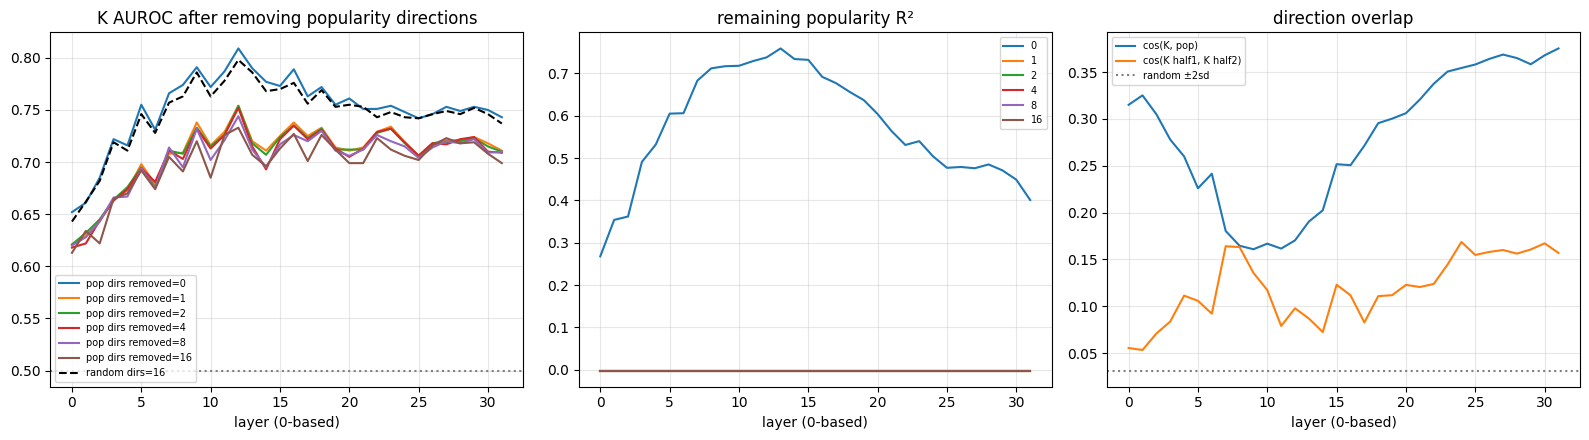

In [15]:
# ===== 10-3. 인지도 방향 제거 후 K 재probe + K·인지도 방향 비교 =====
# 필요한 앞 셀: 1~4, 9-2 (s_pop 병합). 5~10은 생략 가능
# (1) hidden에서 인지도 예측 방향을 1·2·4·8·16개 순차 제거 → K AUROC, 남은 인지도 R² 측정
#     대조: 같은 개수의 무작위 방향 제거 (차원 손실 효과 분리)
# (2) raw 공간에서 K probe 가중치와 인지도 회귀 가중치의 코사인 (상한 기준: K probe 반분 신뢰도)
from sklearn.linear_model import RidgeCV

logpop_ = np.log1p(df['s_pop'].astype(float).values)
POP_ITERS, N_RAND = [1, 2, 4, 8, 16], 3
ALPHAS = np.logspace(-1, 4, 11)
SST = np.sum((logpop_ - logpop_.mean()) ** 2)

def run_popremove(X, seed):
    rng = np.random.default_rng(seed)
    its = [0] + POP_ITERS
    k_s = {it: np.zeros(N) for it in its}; p_s = {it: np.zeros(N) for it in its}
    r_s = {it: np.zeros((N_RAND, N)) for it in POP_ITERS}
    for k in range(N_FOLDS):
        tr, te = FOLD != k, FOLD == k
        Ztr, Zte = pca_block(X[tr], X[te]); d = Ztr.shape[1]
        B = np.zeros((d, 0)); P = np.eye(d)
        for it in range(max(POP_ITERS) + 1):
            if it > 0:   # 현재 공간에서 인지도 회귀 방향을 찾아 누적 제거
                w = RidgeCV(alphas=ALPHAS).fit(Ztr @ P, logpop_[tr]).coef_
                B = np.column_stack([B, P @ w]); Q, _ = np.linalg.qr(B); P = np.eye(d) - Q @ Q.T
            if it in k_s:
                A, At = Ztr @ P, Zte @ P
                k_s[it][te] = lr(PROBE_C).fit(A, yK[tr]).decision_function(At)
                p_s[it][te] = RidgeCV(alphas=ALPHAS).fit(A, logpop_[tr]).predict(At)
                if it > 0:
                    for r in range(N_RAND):
                        Rq, _ = np.linalg.qr(rng.normal(size=(d, it))); Pr = np.eye(d) - Rq @ Rq.T
                        r_s[it][r][te] = lr(PROBE_C).fit(Ztr @ Pr, yK[tr]).decision_function(Zte @ Pr)
    return k_s, p_s, r_s

t0 = time.time()
RES = Parallel(n_jobs=N_JOBS)(delayed(run_popremove)(H[:, L], SEED + L) for L in range(NL))
rows = []
for L, (k_s, p_s, r_s) in enumerate(RES):
    base_auc = auc(yK, k_s[0])
    for it in [0] + POP_ITERS:
        row = dict(layer=L, n_removed=it, auc_K=auc(yK, k_s[it]),
                   pop_R2=1 - np.sum((logpop_ - p_s[it]) ** 2) / SST)
        row['drop_vs_0'] = base_auc - row['auc_K']
        if it > 0:
            ra = [auc(yK, r_s[it][r]) for r in range(N_RAND)]
            row['auc_K_rand'] = np.mean(ra); row['drop_rand'] = base_auc - np.mean(ra)
        if it == max(POP_ITERS):
            ci = np.nanpercentile([auc(yK[i], k_s[it][i]) for i in BOOT], [2.5, 97.5])
            row['ci_lo'], row['ci_hi'] = ci
        rows.append(row)
PR = pd.DataFrame(rows); PR.to_csv(f'{OUT_DIR}/E3_pop_removal.csv', index=False)
print(f'{time.time() - t0:.0f}s')
piv = PR.pivot(index='layer', columns='n_removed', values='auc_K').round(3)
piv_r2 = PR.pivot(index='layer', columns='n_removed', values='pop_R2').round(3)
piv_rd = PR[PR.n_removed == max(POP_ITERS)].set_index('layer')[['auc_K', 'ci_lo', 'ci_hi', 'auc_K_rand', 'drop_vs_0', 'drop_rand']].round(3)
print('(1-a) 인지도 방향 n개 제거 후 K AUROC'); print(piv.to_string())
print('\n(1-b) 제거 후 남은 인지도 R² (0 근처여야 제거 완료)'); print(piv_r2.to_string())
print(f'\n(1-c) {max(POP_ITERS)}개 제거: 인지도 방향 vs 무작위 방향'); print(piv_rd.to_string())

# (2) 방향 비교 (raw 4096 표준화 공간, 전체 데이터로 방향만 추정)
ug = np.unique(groups); rng = np.random.default_rng(SEED + 3)
half = np.isin(groups, rng.choice(ug, len(ug) // 2, replace=False))

def dir_cos(X):
    Xs = StandardScaler().fit_transform(X)
    kdir = lambda m: LogisticRegression(C=PROBE_C, max_iter=3000).fit(Xs[m], yK[m]).coef_[0]
    wk = kdir(np.ones(N, bool)); wk1, wk2 = kdir(half), kdir(~half)
    wp = RidgeCV(alphas=np.logspace(1, 5, 9)).fit(Xs, logpop_).coef_
    c = lambda a, b: float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))
    return c(wk, wp), c(wk1, wk2)

CS = Parallel(n_jobs=N_JOBS)(delayed(dir_cos)(H[:, L]) for L in range(NL))
COS = pd.DataFrame({'layer': range(NL), 'cos_K_pop': [c[0] for c in CS], 'cos_K_half_reliability': [c[1] for c in CS]})
COS['random_2sd'] = 2 / np.sqrt(H.shape[2])
COS.to_csv(f'{OUT_DIR}/E3_direction_cosine.csv', index=False)
print('\n(2) K probe 방향 vs 인지도 방향 코사인'); print(COS.round(3).to_string(index=False))

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5)); Ls = np.arange(NL)
for it in [0] + POP_ITERS:
    ax[0].plot(Ls, piv[it], label=f'pop dirs removed={it}')
ax[0].plot(Ls, piv_rd['auc_K_rand'], 'k--', label=f'random dirs={max(POP_ITERS)}')
ax[0].axhline(0.5, ls=':', c='gray'); ax[0].set_title('K AUROC after removing popularity directions')
for it in [0] + POP_ITERS: ax[1].plot(Ls, piv_r2[it], label=f'{it}')
ax[1].set_title('remaining popularity R²')
ax[2].plot(Ls, COS['cos_K_pop'], label='cos(K, pop)'); ax[2].plot(Ls, COS['cos_K_half_reliability'], label='cos(K half1, K half2)')
ax[2].axhline(COS['random_2sd'][0], ls=':', c='gray', label='random ±2sd'); ax[2].set_title('direction overlap')
for a in ax: a.set_xlabel('layer (0-based)'); a.legend(fontsize=7); a.grid(alpha=.3)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/E3_summary.png', dpi=150); plt.show()

139s
K AUROC by removal condition
 layer  auc_M0  auc_M1  auc_M2  auc_M3  auc_M4  auc_R4
     0   0.652   0.553   0.621   0.525   0.490   0.619
     1   0.661   0.600   0.632   0.563   0.519   0.617
     2   0.685   0.615   0.645   0.575   0.526   0.643
     3   0.722   0.655   0.664   0.591   0.525   0.684
     4   0.716   0.651   0.676   0.576   0.490   0.673
     5   0.755   0.691   0.695   0.610   0.549   0.723
     6   0.731   0.682   0.676   0.604   0.560   0.699
     7   0.766   0.690   0.711   0.597   0.561   0.720
     8   0.774   0.689   0.708   0.608   0.533   0.715
     9   0.791   0.716   0.733   0.652   0.544   0.751
    10   0.772   0.677   0.715   0.602   0.543   0.734
    11   0.787   0.691   0.726   0.606   0.569   0.723
    12   0.809   0.721   0.754   0.631   0.583   0.748
    13   0.790   0.694   0.718   0.596   0.516   0.700
    14   0.777   0.687   0.707   0.585   0.522   0.708
    15   0.773   0.704   0.724   0.626   0.559   0.724
    16   0.789   0.733   0.735 

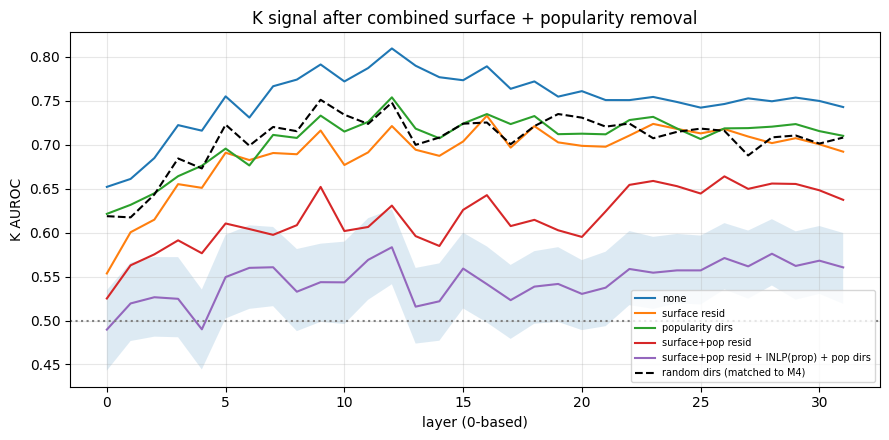

In [16]:
# ===== 10-4. 결합 제거: 표면 + 인지도를 동시에 지운 뒤 K 재probe (E2b 최종 판정) =====
# 필요한 앞 셀: 1~4, 9-2 (5~10, 10-2, 10-3은 생략 가능)
# 조건 (모두 in-fold PCA 256 공간, 제거 규칙은 학습 fold에서만 적합)
#   M0 제거 없음
#   M1 표면 잔차화 (TF-IDF SVD50 + prop one-hot)          = 실험 C
#   M2 인지도 방향 4개 제거                                 = 10-3
#   M3 표면 + 인지도 동시 잔차화
#   M4 M3 + INLP(prop) + 인지도 방향 4개 제거 (가장 강한 제거)
#   R4 M4와 같은 차원 수만큼 무작위 방향 제거 (차원 손실 대조)
from sklearn.linear_model import RidgeCV
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder

logpop_ = np.log1p(df['s_pop'].astype(float).values)
ALPHAS = np.logspace(-2, 4, 13); N_POPDIR = 4; SST = np.sum((logpop_ - logpop_.mean()) ** 2)

def surface_dense(tr, te):
    tf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True).fit(qtext[tr])
    Ttr, Tte = tf.transform(qtext[tr]), tf.transform(qtext[te])
    svd = TruncatedSVD(min(50, Ttr.shape[1] - 1), random_state=SEED).fit(Ttr)
    oh = OneHotEncoder(handle_unknown='ignore', sparse_output=False).fit(props[tr].reshape(-1, 1))
    f = lambda T, idx: np.hstack([svd.transform(T), oh.transform(props[idx].reshape(-1, 1))])
    return f(Ttr, tr), f(Tte, te)

SURF_D = {k: surface_dense(np.where(FOLD != k)[0], np.where(FOLD == k)[0]) for k in range(N_FOLDS)}

def proj_from(B, d):
    if B.shape[1] == 0: return np.eye(d)
    U, sv, _ = np.linalg.svd(B, full_matrices=False); U = U[:, sv > 1e-8 * sv.max()]
    return np.eye(d) - U @ U.T

def remove_pop_dirs(Ztr, target, P0, n):
    d = Ztr.shape[1]; B = np.eye(d) - P0; B = B[:, np.linalg.norm(B, axis=0) > 1e-8]; P = P0
    for _ in range(n):
        w = RidgeCV(alphas=ALPHAS).fit(Ztr @ P, target).coef_
        B = np.column_stack([B, P @ w]); P = proj_from(B, d)
    return P

def inlp_dirs(Z, lab, iters=INLP_ITERS):
    d = Z.shape[1]; Ws = []; P = np.eye(d)
    for _ in range(iters):
        Ws.append(LogisticRegression(C=1.0, max_iter=2000).fit(Z @ P, lab).coef_.T)
        P = proj_from(np.hstack(Ws), d)
    return P

def run_combo(X, seed):
    rng = np.random.default_rng(seed)
    S = {m: np.zeros(N) for m in ('M0', 'M1', 'M2', 'M3', 'M4', 'R4')}
    popR2_pred = np.zeros(N); prop_acc, rank = [], []
    for k in range(N_FOLDS):
        tr, te = FOLD != k, FOLD == k
        Ztr, Zte = pca_block(X[tr], X[te]); d = Ztr.shape[1]
        Str, Ste = SURF_D[k]
        fit = lambda A, At: lr(PROBE_C).fit(A, yK[tr]).decision_function(At)
        S['M0'][te] = fit(Ztr, Zte)
        r1 = RidgeCV(alphas=ALPHAS).fit(Str, Ztr)                                  # M1
        S['M1'][te] = fit(Ztr - r1.predict(Str), Zte - r1.predict(Ste))
        P2 = remove_pop_dirs(Ztr, logpop_[tr], np.eye(d), N_POPDIR)                 # M2
        S['M2'][te] = fit(Ztr @ P2, Zte @ P2)
        Ftr = np.column_stack([Str, logpop_[tr]]); Fte = np.column_stack([Ste, logpop_[te]])
        r3 = RidgeCV(alphas=ALPHAS).fit(Ftr, Ztr)                                  # M3
        Rtr, Rte = Ztr - r3.predict(Ftr), Zte - r3.predict(Fte)
        S['M3'][te] = fit(Rtr, Rte)
        P4 = inlp_dirs(Rtr, props[tr])                                            # M4
        P4 = remove_pop_dirs(Rtr, logpop_[tr], P4, N_POPDIR)
        A4, At4 = Rtr @ P4, Rte @ P4
        S['M4'][te] = fit(A4, At4)
        popR2_pred[te] = RidgeCV(alphas=ALPHAS).fit(A4, logpop_[tr]).predict(At4)
        prop_acc.append(LogisticRegression(C=1.0, max_iter=2000).fit(A4, props[tr]).score(At4, props[te]))
        nr = d - int(round(np.trace(P4))); rank.append(nr)                         # R4
        Q, _ = np.linalg.qr(rng.normal(size=(d, nr))); Pr = np.eye(d) - Q @ Q.T
        S['R4'][te] = fit(Ztr @ Pr, Zte @ Pr)
    return S, popR2_pred, np.mean(prop_acc), np.mean(rank)

t0 = time.time()
RES4 = Parallel(n_jobs=N_JOBS)(delayed(run_combo)(H[:, L], SEED + 100 + L) for L in range(NL))
maj = pd.Series(props).value_counts(normalize=True).iloc[0]
rows = []
for L, (S, pp, pa, rk) in enumerate(RES4):
    row = dict(layer=L, **{f'auc_{m}': auc(yK, s) for m, s in S.items()},
               M4_pop_R2=1 - np.sum((logpop_ - pp) ** 2) / SST, M4_prop_acc=pa, prop_majority=maj, M4_dims_removed=rk)
    for m in ('M3', 'M4'):
        row[f'{m}_ci_lo'], row[f'{m}_ci_hi'] = np.nanpercentile([auc(yK[i], S[m][i]) for i in BOOT], [2.5, 97.5])
    row['M4_specific_drop'] = row['auc_R4'] - row['auc_M4']
    rows.append(row)
CB = pd.DataFrame(rows); CB.to_csv(f'{OUT_DIR}/E4_combined_removal.csv', index=False)
print(f'{time.time() - t0:.0f}s')
print('K AUROC by removal condition'); print(CB[['layer', 'auc_M0', 'auc_M1', 'auc_M2', 'auc_M3', 'auc_M4', 'auc_R4']].round(3).to_string(index=False))
print('\nM3·M4 CI 및 제거 점검'); print(CB[['layer', 'M3_ci_lo', 'M3_ci_hi', 'M4_ci_lo', 'M4_ci_hi', 'M4_specific_drop',
                                        'M4_pop_R2', 'M4_prop_acc', 'prop_majority', 'M4_dims_removed']].round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5)); Ls = np.arange(NL)
lab = {'M0': 'none', 'M1': 'surface resid', 'M2': 'popularity dirs', 'M3': 'surface+pop resid',
       'M4': 'surface+pop resid + INLP(prop) + pop dirs', 'R4': 'random dirs (matched to M4)'}
for m in ('M0', 'M1', 'M2', 'M3', 'M4'): ax.plot(Ls, CB[f'auc_{m}'], label=lab[m])
ax.plot(Ls, CB['auc_R4'], 'k--', label=lab['R4'])
ax.fill_between(Ls, CB['M4_ci_lo'], CB['M4_ci_hi'], alpha=.15)
ax.axhline(0.5, ls=':', c='gray'); ax.set_xlabel('layer (0-based)'); ax.set_ylabel('K AUROC'); ax.legend(fontsize=7); ax.grid(alpha=.3)
ax.set_title('K signal after combined surface + popularity removal')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/E4_combined_removal.png', dpi=150); plt.show()

        metric  best_layer_calib  calib_value  test_value
0  K_probe_raw                10        0.823       0.788
1      B_delta                 9        0.072       0.092


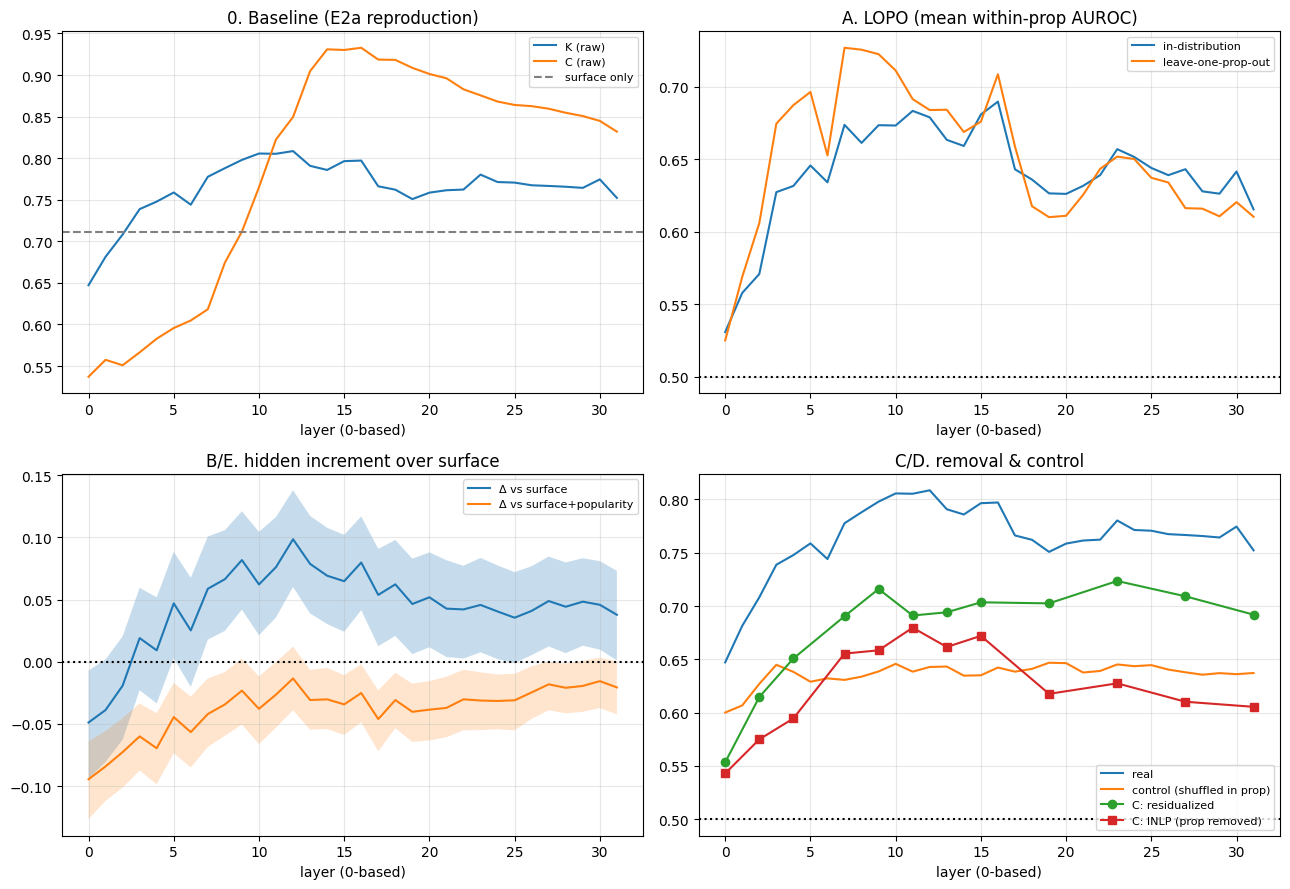

저장: /content/drive/MyDrive/p8s/E2b_surface_vs_knowledge


In [14]:
# ===== 11. 층 선택 calibration/test 분리 + 요약 그림 =====
# 질문을 K 비율 유지하며 절반씩 나눔 → calib에서 최고 층 선택, test에서 값 보고 (사후 선택 방지)
ug = np.unique(groups); gk = np.array([yK[groups == g][0] for g in ug])
rng = np.random.default_rng(SEED + 11); calib_g = set()
for c in (0, 1):
    gs = ug[gk == c]; calib_g |= set(rng.choice(gs, len(gs) // 2, replace=False))
cal = np.isin(groups, list(calib_g)); tst = ~cal

sel = []
metrics = {'K_probe_raw': lambda L, m: auc(yK[m], OOF_K[L][m]),
           'B_delta': lambda L, m: auc(yK[m], OOF_SH[L][m]) - auc(yK[m], S_TE[m])}
for name, f in metrics.items():
    cal_v = [f(L, cal) for L in range(NL)]; Lb = int(np.nanargmax(cal_v))
    sel.append(dict(metric=name, best_layer_calib=Lb, calib_value=cal_v[Lb], test_value=f(Lb, tst)))
sel = pd.DataFrame(sel); sel.to_csv(f'{OUT_DIR}/layer_selection.csv', index=False); print(sel.round(3))

fig, ax = plt.subplots(2, 2, figsize=(13, 9)); Ls = np.arange(NL)
ax[0, 0].plot(Ls, base['auc_K'], label='K (raw)'); ax[0, 0].plot(Ls, base['auc_C'], label='C (raw)')
ax[0, 0].axhline(auc(yK, S_TE), ls='--', c='gray', label='surface only')
ax[0, 0].set_title('0. Baseline (E2a reproduction)')
ax[0, 1].plot(Ls, A_sum['indist_mean'], label='in-distribution'); ax[0, 1].plot(Ls, A_sum['lopo_mean'], label='leave-one-prop-out')
ax[0, 1].axhline(0.5, ls=':', c='k'); ax[0, 1].set_title('A. LOPO (mean within-prop AUROC)')
ax[1, 0].plot(Ls, B_sum['delta'], label='Δ vs surface')
ax[1, 0].fill_between(Ls, B_sum['ci_lo'], B_sum['ci_hi'], alpha=.25)
if 'E_sum' in globals():
    ax[1, 0].plot(Ls, E_sum['delta'], label='Δ vs surface+popularity')
    ax[1, 0].fill_between(Ls, E_sum['ci_lo'], E_sum['ci_hi'], alpha=.2)
ax[1, 0].axhline(0, ls=':', c='k'); ax[1, 0].set_title('B/E. hidden increment over surface')
ax[1, 1].plot(Ls, D_sum['auc_real'], label='real'); ax[1, 1].plot(Ls, D_sum['auc_ctrl_mean'], label='control (shuffled in prop)')
ax[1, 1].plot(C_sum['layer'], C_sum['auc_resid'], 'o-', label='C: residualized')
ax[1, 1].plot(C_sum['layer'], C_sum['auc_inlp'], 's-', label='C: INLP (prop removed)')
ax[1, 1].axhline(0.5, ls=':', c='k'); ax[1, 1].set_title('C/D. removal & control')
for a in ax.flat: a.set_xlabel('layer (0-based)'); a.legend(fontsize=8); a.grid(alpha=.3)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/E2b_summary.png', dpi=150); plt.show()
print('저장:', OUT_DIR)